<a href="https://colab.research.google.com/github/lipikashrivastava388-bit/Ai-ML/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
cols = ["area", "parameter", "compactness", "length", "asymmentry", "width", "groove", "class"]
df = pd.read_csv("seeds_dataset.txt", names=cols, sep="\s+") #sep=/s+ means all spaces are seen as data separaters

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6521/421508719.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("seeds_dataset.txt", names=cols, sep="\s+") #sep=/s+ means all spaces are seen as data separaters


In [33]:
df.head()

,area,parameter,compactness,length,asymmentry,width,groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


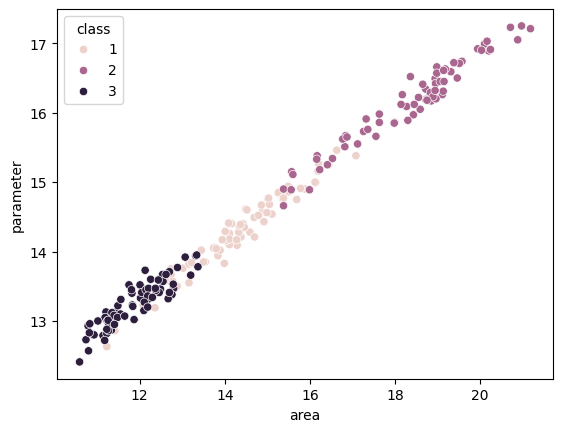

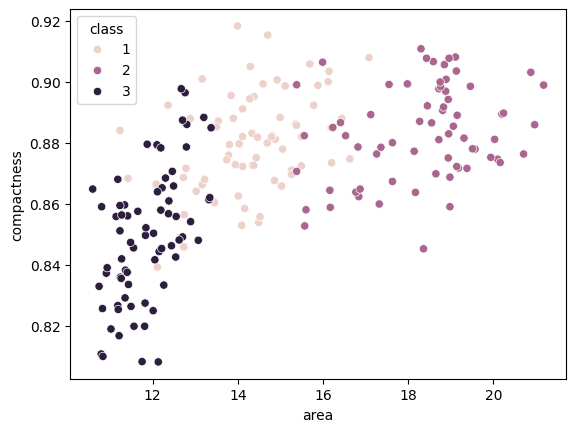

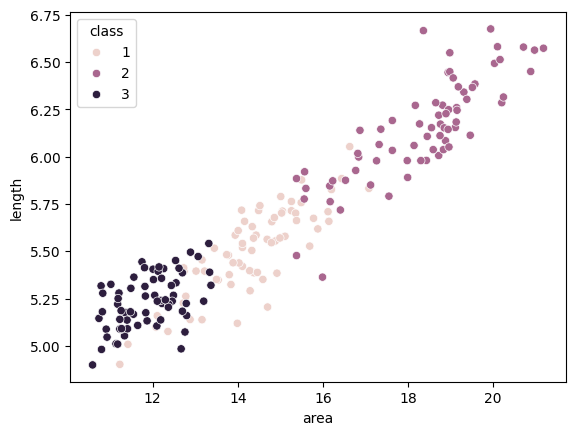

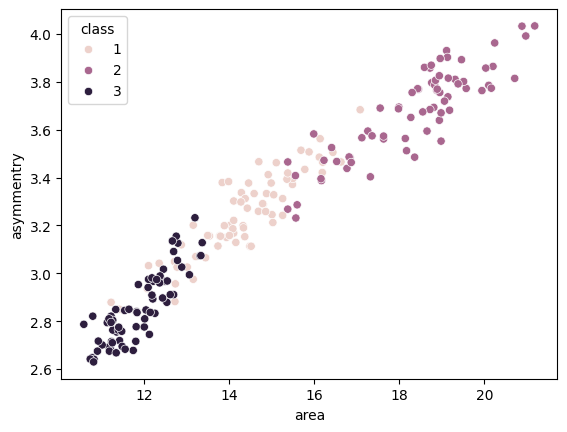

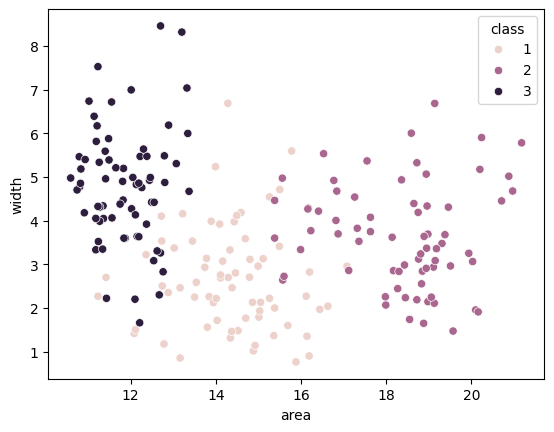

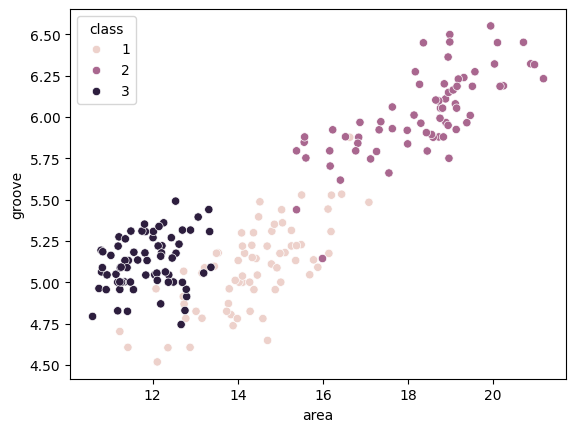

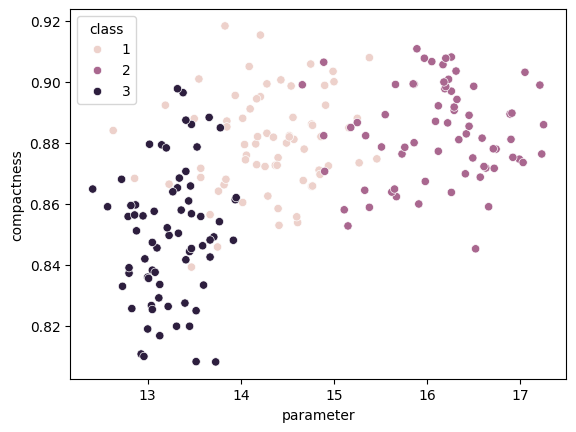

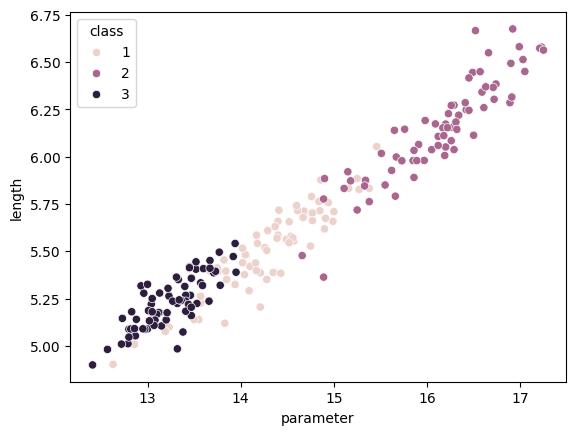

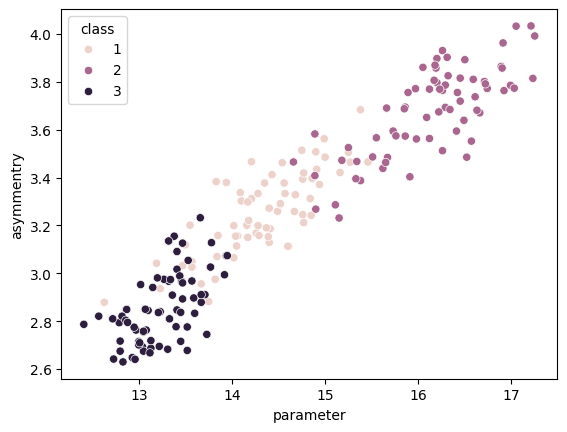

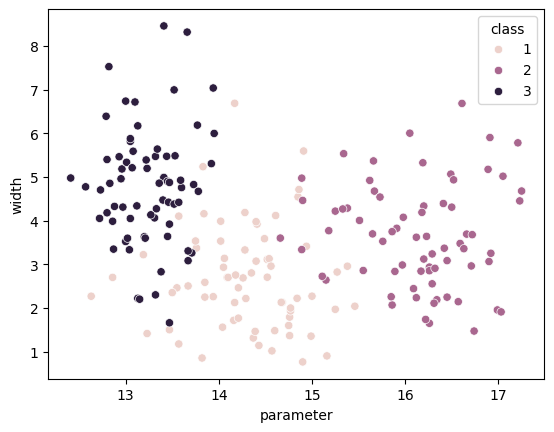

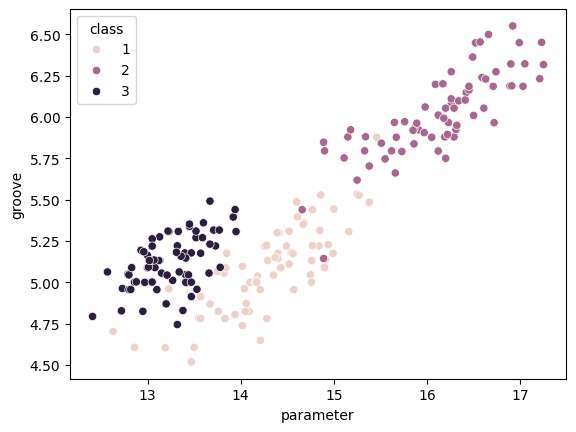

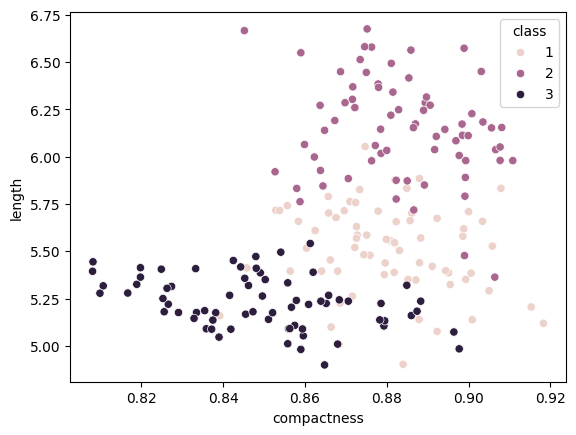

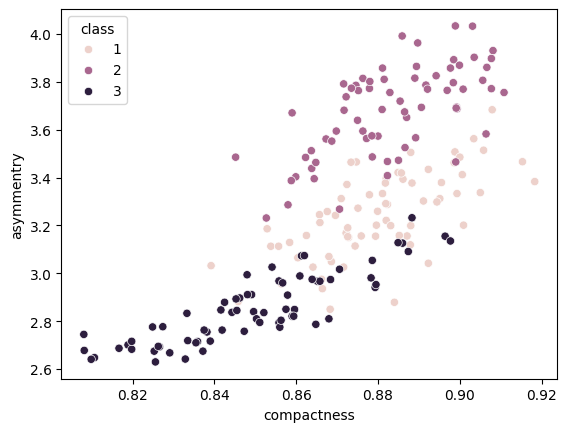

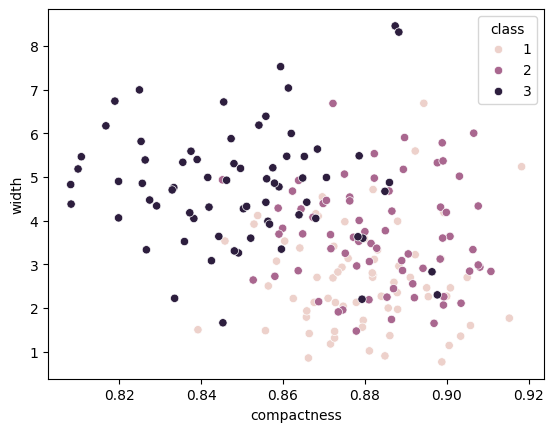

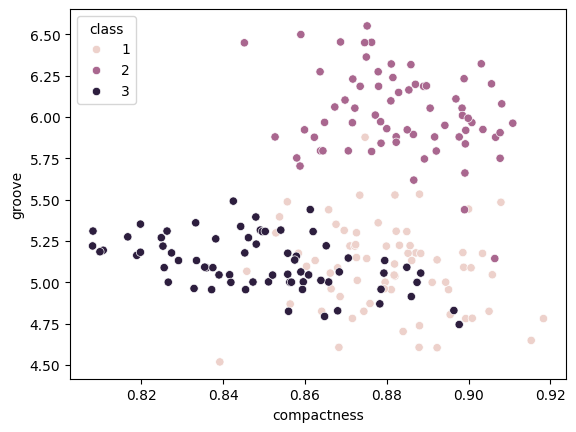

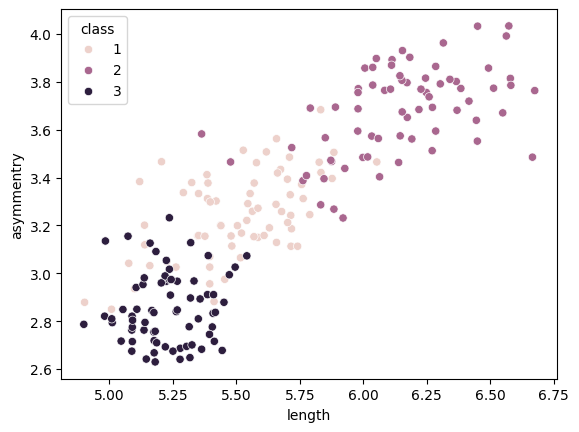

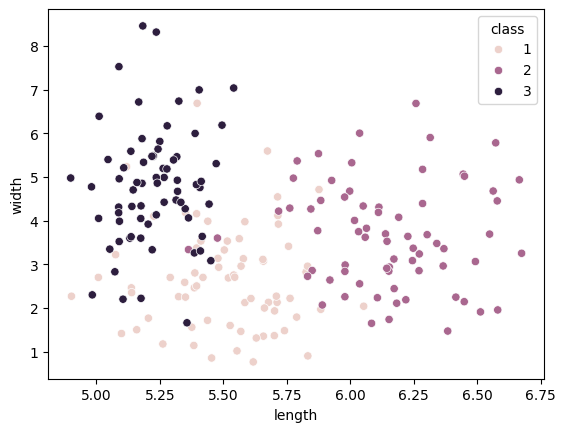

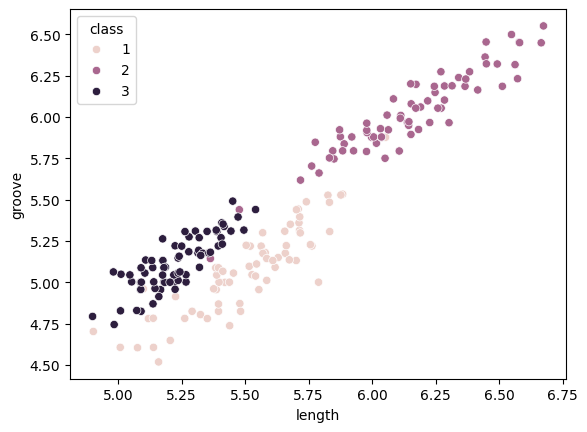

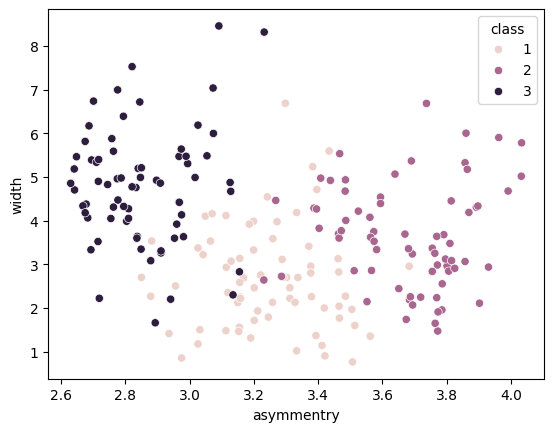

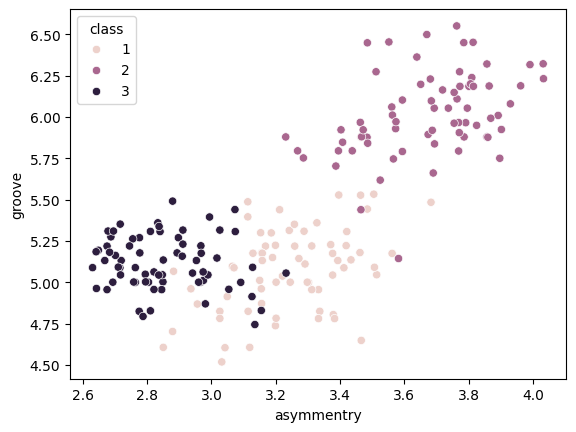

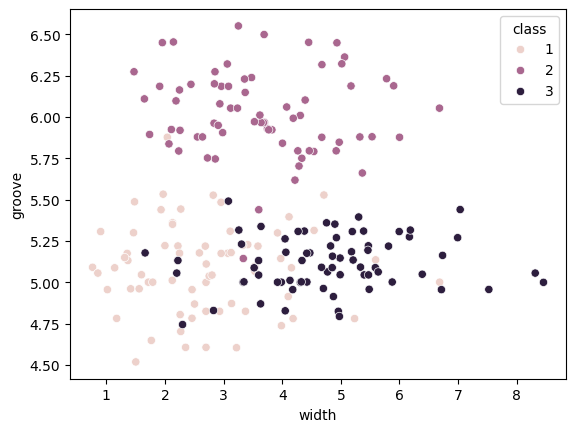

In [34]:
# in unsupervised learning we dont have acess to the class
#this will give us grid of all different combinations
for i in range(len(cols)-1):
  for j in range(i+1, len(cols)-1):
    x_label = cols[i]
    y_label = cols [j]
    sns.scatterplot(x=x_label, y=y_label, data=df, hue='class')
    plt.show()


## Clustering

In [35]:
from sklearn.cluster import KMeans

In [48]:
# taking those which are not clustered in graphs
x = "compactness"
y = "asymmentry"
X = df[[x,y]].values

In [49]:
kmeans = KMeans(n_clusters = 3).fit(X)

In [50]:
clusters = kmeans.labels_

In [51]:
clusters

array([2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2,
       1, 0, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 2, 2, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 1, 1, 2, 2, 1, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2,
       0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0], dtype=int32)

In [52]:
df["class"].values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [53]:
cluster_df = pd.DataFrame(np.hstack((X, clusters.reshape(-1,1))), columns=[x, y, "class"])
#hstack = horizontally stacked, inputing 2 values in reshaping means converting it into 2D

[]

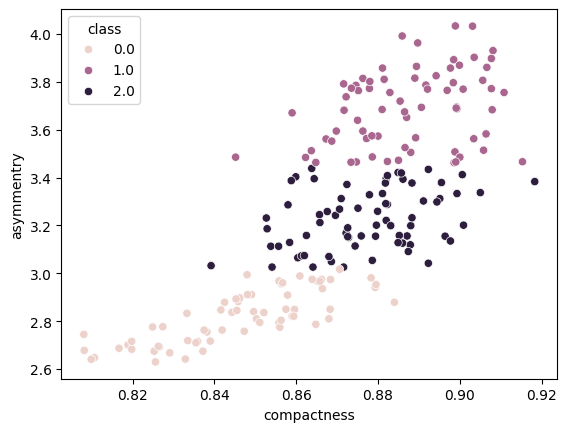

In [54]:
# K Means classes
sns.scatterplot(x=x, y=y, hue='class', data=cluster_df)
plt.plot()

[]

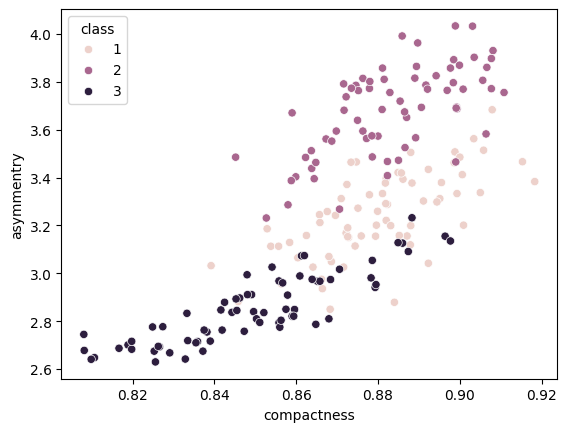

In [55]:
# Original classes
sns.scatterplot(x=x, y=y, hue='class', data=df)
plt.plot()

## Higher Dimensions

In [56]:
X = df[cols[:-1]].values

In [60]:
kmeans = KMeans(n_clusters = 3).fit(X)
cluster_df = pd.DataFrame(np.hstack((X, kmeans.labels_.reshape(-1,1))), columns=df.columns)

[]

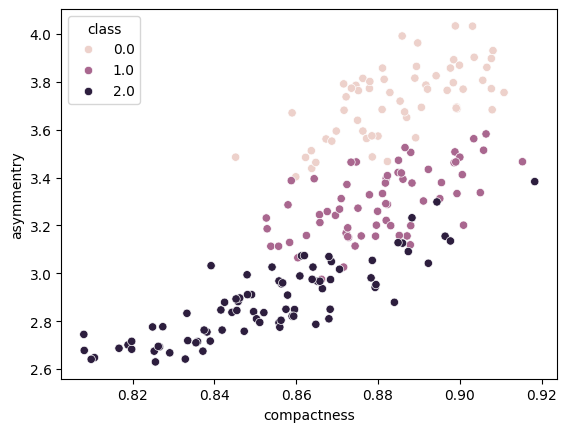

In [61]:
# K Means classes
sns.scatterplot(x=x, y=y, hue='class', data=cluster_df)
plt.plot()

[]

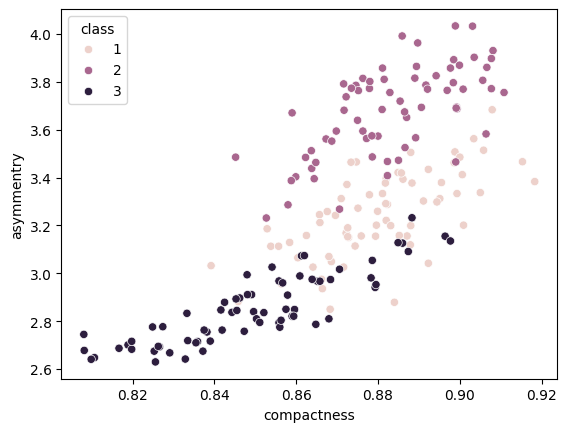

In [62]:
# Original classes
sns.scatterplot(x=x, y=y, hue='class', data=df)
plt.plot()

## PCA

In [65]:
from sklearn.decomposition import PCA

In [69]:
pca = PCA(n_components=2) #2D
transformed_x = pca.fit_transform(X)

In [71]:
X.shape #210 samples each of 7 features

(210, 7)

In [73]:
transformed_x.shape #2d

(210, 2)

In [74]:
transformed_x[:5]

array([[ 0.66344838, -1.41732098],
       [ 0.31566651, -2.68922915],
       [-0.6604993 , -1.13150635],
       [-1.0552759 , -1.62119002],
       [ 1.61999921, -2.18338442]])

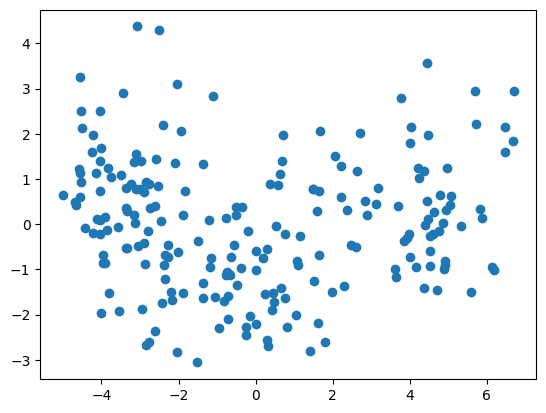

In [76]:
 plt.scatter(transformed_x[:,0], transformed_x[:,1])
 plt.show()
 # trasformed 7 dimensions into 2

In [78]:
kmeans_pca_df = pd.DataFrame(np.hstack((transformed_x, kmeans.labels_.reshape(-1, 1))), columns=["pca1","pca2", "class"])

In [79]:
truth_pca_df = pd.DataFrame(np.hstack((transformed_x, df["class"].values.reshape(-1, 1))), columns=["pca1","pca2", "class"])

[]

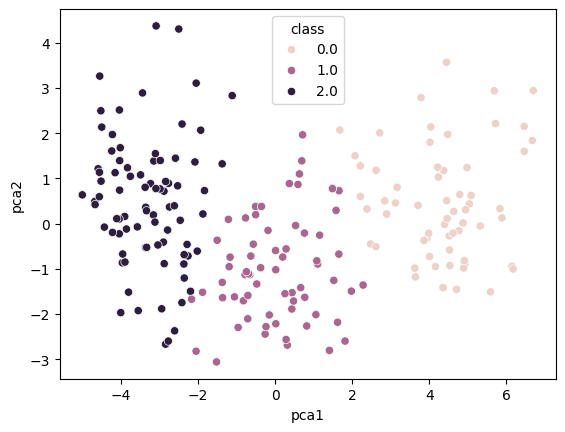

In [83]:
# K Means classes
sns.scatterplot(x="pca1", y="pca2", hue='class', data=kmeans_pca_df)
plt.plot()

[]

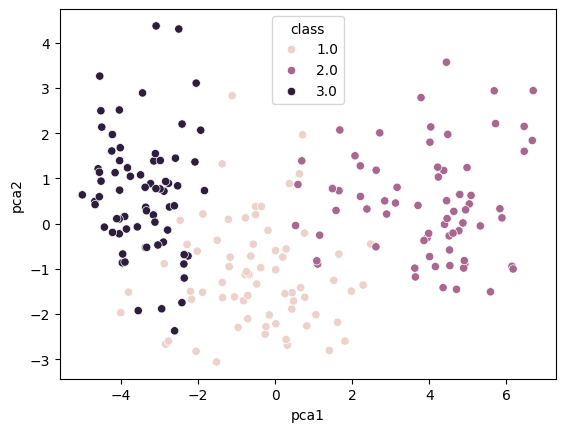

In [84]:
# Original classes
sns.scatterplot(x="pca1", y="pca2", hue='class', data=truth_pca_df)
plt.plot()